# Time Series With Deep Learning

LSTM(Long Short Time Memory) Gelecek zaman serisi, metin serisi tahmin eder

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, LSTM

In [2]:
df=pd.read_csv('Google_Stock_Price_Train.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [5]:
train_set=df.iloc[:,1:2].values

In [7]:
sc=MinMaxScaler()

In [8]:
train_set=sc.fit_transform(train_set)

In [9]:
train_set

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [10]:
x_train=train_set[0:1257]
y_train=train_set[1:1258]

In [11]:
model=Sequential()
model.add(LSTM(units=4,activation='sigmoid', input_shape=(None,1)))
model.add(Dense(units=1))

C:\Users\kosey\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [13]:
model.fit(x_train,y_train, batch_size=32, epochs=200)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2926 
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2106 
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1540 
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1174 
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0956 
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0776 
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0745 
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0725 
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0710 
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0697 
Epoch 12/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0684 
Epoch 13/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0670 
Epoch 14/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0656 
Epoch 15/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

In [14]:
test=pd.read_csv('Google_Stock_Price_Test.csv')

In [15]:
test=test.iloc[:,1:2].values

In [20]:
test_set=sc.transform(test)

In [21]:
tahmin=model.predict(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


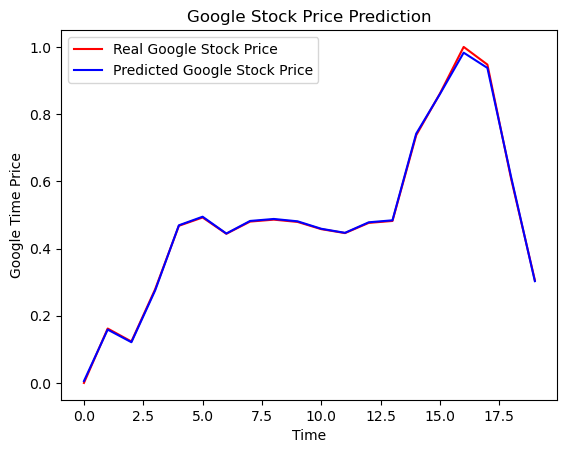

In [22]:
plt.plot(test_set, color = 'red', label = 'Real Google Stock Price')
plt.plot(tahmin, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Time Price')
plt.legend()
plt.show()